# Notebook 03 — Isosteric Heat of Adsorption (Figure F3)

The isosteric heat q_st is the differential enthalpy released when hydrogen adsorbs
at fixed coverage. It is the thermodynamic meaning of "binding energy" at tank scale
and sets the thermal load the system must reject during a fill. For hydrogen physisorbed
on carbons the accepted low-coverage value is 4–7 kJ/mol; a model that reproduces that
range from the published AX-21 D–A parameters is behaving physically. This notebook
computes q_st from the D–A isotherm by numerical Clausius–Clapeyron and plots it against
coverage (Figure F3), with the carbon literature band shaded.

In [10]:
from pathlib import Path
import matplotlib.pyplot as plt
from h2star.isotherm import Material, ModifiedDA
from h2star.viz import plot_isosteric_heat

assert Path.cwd().name == "h2star", f"run from repo root, cwd={Path.cwd()}"
FIG_DIR = Path.cwd() / "figures"
FIG_DIR.mkdir(exist_ok=True)

In [11]:
mat = Material.from_yaml("data/materials/ax21.yaml")
da = ModifiedDA(mat)

Gate V2 (isosteric-heat clause) was pre-registered before this computation: q_st across
n/n_max ∈ [0.05, 0.15] must fall within 4–7 kJ/mol, decrease monotonically in coverage,
and match the closed-form D–A limit q_st = alpha·sqrt(ln(n_max/n)) at n/n_max = 0.10.
The analytic limit follows because ln P is exactly affine in 1/T at fixed coverage for
this model; beta cancels and q_st is temperature-independent.

wrote /Users/avingupta/Documents/research/h2star/figures/F3_isosteric_heat.png


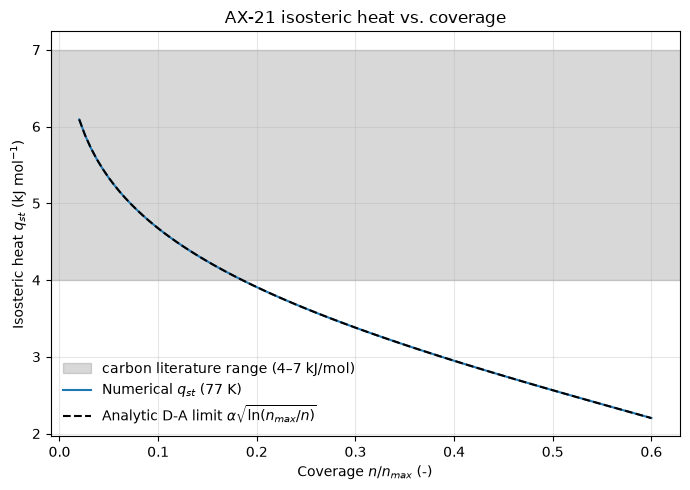

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))
plot_isosteric_heat(da, ax=ax)
fig.tight_layout()
out = FIG_DIR / "F3_isosteric_heat.png"
fig.savefig(out, dpi=300)
print(f"wrote {out}")

Result. Across the anchor window the model gives q_st = 5.33, 4.67, 4.24 kJ/mol at
n/n_max = 0.05, 0.10, 0.15, all inside the 4–7 kJ/mol carbon band, decreasing with
coverage as strong sites fill first. The numerical curve and the analytic D–A limit
coincide to machine precision. Gate V2's isosteric-heat clause therefore PASSES.

Limitation. The D–A form gives q_st → ∞ as n → 0 (a sqrt-ln divergence), which is an
artifact of the functional form rather than a physical zero-coverage heat; a real
material plateaus at a finite value set by its strongest sites. The anchor is evaluated
at finite low coverage and F3 is truncated at n/n_max = 0.02 for this reason. This
functional-form limitation is carried into the limitations section (§3.13).